In [ ]:
#LangSmith Setup
import os
from dotenv import load_dotenv

load_dotenv(override=True)

print(os.getenv("LANGSMITH_API_KEY"))
print(os.getenv("LANGSMITH_TRACING"))
print(os.getenv("LANGSMITH_ENDPOINT"))
print(os.getenv("LANGSMITH_PROJECT"))
print(os.getenv("OPENAI_API_KEY"))

In [49]:
from langchain_ollama import ChatOllama

#LLM
llm = ChatOllama(
    model="qwen3:1.7b", #  phi3, gemma3:12b, gpt-oss:20b, qwen3:1.7b,
    temperature=0,
    base_url="http://localhost:11434/"
)

In [50]:
from langchain_community.utilities import SQLDatabase
db = SQLDatabase.from_uri(r"sqlite:///C:\Users\peter\Documents\SJSU\Thesis\code\mini_dev\minidev_0703\minidev\MINIDEV\dev_databases\debit_card_specializing\debit_card_specializing.sqlite")

In [51]:
from langchain_core.tools import tool

# Define tools
@tool
def show_tables() -> str:
    """Retrieves all available tables in database by running "SELECT name FROM sqlite_master WHERE type='table';".
    
    Args:
        No Args
    """
    query = "SELECT name FROM sqlite_master WHERE type='table';"
    return db.run(query)

@tool
def get_table_schema(table_name: str) -> str:
    """Get detailed information about a table including columns, types, and constraints.
    
    Args:
        table_name: Name of the table to describe
    """
    # Get column information
    query = f"PRAGMA table_info({table_name});"
    return db.run(query)

@tool
def execute_query(query: str) -> str:
    """Execute a SQL SELECT query and return the results.
    
    Only SELECT statements are permitted for data safety.
    Returns formatted results or error messages.
    
    Args:
        query: The SQL SELECT query to execute
    """
    # Strip whitespace and check query type
    query_stripped = query.strip()
    query_upper = query_stripped.upper()
    
    # Block non-SELECT queries
    dangerous_keywords = ['INSERT', 'UPDATE', 'DELETE', 'DROP', 'CREATE', 'ALTER', 'TRUNCATE']
    if any(query_upper.startswith(keyword) for keyword in dangerous_keywords):
        return f"Error: Only SELECT queries are allowed. Detected forbidden operation."
    
    if not query_upper.startswith('SELECT'):
        return "Error: Query must start with SELECT."
    
    try:
        result = db.run(query_stripped)
        if not result or result.strip() == '':
            return "Query executed successfully but returned no results."
        return result
    except Exception as e:
        return f"Error executing query: {str(e)}\nQuery was: {query_stripped}"

tools = [show_tables, get_table_schema, execute_query]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [52]:
from langgraph.graph import MessagesState, START, END
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

from typing_extensions import Literal

# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages":[
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful SQL generation agent designed to generate {dialect} to handle the user task."
                    )
                ]
                + state["messages"]
            )
        ]
    }

def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages":result}

def should_continue(state: MessagesState) -> Literal["environment", END]:
    """Decide if we should continue the loop or stop base upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop
    return END

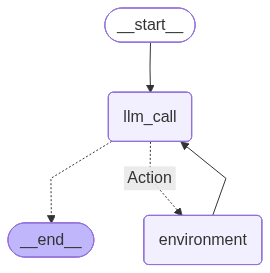

In [53]:
from langgraph.graph import StateGraph

from IPython.display import Image, display

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        # Name returned by should_continue : Name of next node to visit
        "Action" : "environment",
        END: END,
    }
)
agent_builder.add_edge("environment", "llm_call")

agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="Get 5 examples products in the database.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Get 5 examples procudts in the database.
================================== Ai Message ==================================
Tool Calls:
  show_tables (e0dcb710-7050-4570-8ebf-abd9cd373251)
 Call ID: e0dcb710-7050-4570-8ebf-abd9cd373251
  Args:
================================= Tool Message =================================

[('customers',), ('gasstations',), ('products',), ('transactions_1k',), ('sqlite_sequence',), ('yearmonth',)]
================================== Ai Message ==================================
Tool Calls:
  get_table_schema (fac40593-2828-4679-8bf1-d2cdfcd9ef66)
 Call ID: fac40593-2828-4679-8bf1-d2cdfcd9ef66
  Args:
    table_name: products
================================= Tool Message =================================

[(0, 'ProductID', 'INTEGER', 1, None, 1), (1, 'Description', 'TEXT', 0, None, 0)]
================================== Ai Message ==================================
Tool Cal

Custome tools work, this workflow feels very intuative and I am excited to start exploring different applications with it.

Now it is time to figure out if these basic tools and small model (qwen3:1.7b) can figure out the basic BIRD questions.

*

*

*

*

*

## Experimenting with BIRD Questions

In [56]:
import json

with open('..\mini_dev\mini_dev_data\mini_dev_sqlite.json') as f:
    mini_dev_sqlite = json.load(f)

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\peter\AppData\Local\Temp\ipykernel_22772\780049342.py:3: SyntaxWarning: invalid escape sequence '\m'
  with open('..\mini_dev\mini_dev_data\mini_dev_sqlite.json') as f:


In [ ]:
# Bird Question 1 with evidence
entry = mini_dev_sqlite[0]
messages = [HumanMessage(content="{question} You may find it helpful to know: {evidence}".format(question = entry['question'], evidence = entry['evidence']))]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the ratio of customers who pay in EUR against customers who pay in CZK? You may find it helpful to know: ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').
================================== Ai Message ==================================
Tool Calls:
  show_tables (ce50f19c-6245-434a-b35f-8d27dc167806)
 Call ID: ce50f19c-6245-434a-b35f-8d27dc167806
  Args:
  get_table_schema (a55e4a78-29ae-4526-9165-7d144e1995c1)
 Call ID: a55e4a78-29ae-4526-9165-7d144e1995c1
  Args:
    table_name: payments
  execute_query (59258fea-bf86-47f4-9a9f-066c138b2218)
 Call ID: 59258fea-bf86-47f4-9a9f-066c138b2218
  Args:
    query: SELECT COUNT(*) as eur_count FROM payments WHERE Currency = 'EUR'; SELECT COUNT(*) as czk_count FROM payments WHERE Currency = 'CZK';
================================= Tool Message =================================

[('custom

Bird Question #1 w/ evidence Success rate: 2/3 (3:07PM 2/17/26)

Looks like the basic tools and small LLM can handle a basic question, the accuracy/reliability is still in question. 

I am intrigued by the LLM calling multiple tool calls at once. In my minds eye, the LLM would call get_tables, wait for a response, call get_table_schema, wait for response, etc. Calling multiple tools at one time could be useful. Problem with the current usage of these tools is the get_table_schema and run_query are both wrong everytime because the model does not know anything about the database. At the moment I dont beleive any of these early error prone calls are causing a problem such as increasing latency, or using up extra resources, so no apparent reseaon to prevent it at this point.

More testing could be done with these tools on this model, however it is unlikely this will be a baseline of anykind so I dont think that is neccesary. A more appropiate baseline would have no agents, just the available database schemas, and an LLM to generate SQL, and maybe an LLM to check errors. Now that I am comfortable with how to use langgraph, I will move onto Version 1.0 where I will develope a baseline and some prototypes for the final pipeline. 

Idea for the final pipeline will likely include:
1. A preliminary research phase that uses static function to retrieve the name of all tables, relavent tables values (found through locality-sensitive hashing (LSH) inspired by CHASE-SQL) 
2. A dynamic agent phase in which an agent is given tools to querying the database for information that was not found in the research phase, and 
3. A generation phase, possibly using parralization, evaluator-optimizers, and/or live database access for running the generated queries.

Possible Optimizations:
* Use different size models and different types of models at each point in the process. The dynamic agent phase may only need a small model whie the query generation phase may need something larger.
* How much research do we leave to the preliminary phase and how much do we leave to the agent?
* How much will creating multple candidates by using parralization for the final response increase accuracy/reliability vs increase latency?
* I still am very curious about adding example user questions and queries, that would go into the preliminary phase.

Concerns for Thesis and Publication
* This could get pretty close to being a copy of CHASE SQL if I am not careful, I wonder if adding in the agent component between the LSH and Cadidate generation of CHASE will qualify it as novel.
* While I am curious about adding example user_question/gold_query pairs, I am almost certain that would disqualify me from adding my method to the BIRD leaderboards. Additionally how would I make sure the pairs did not provide the answer to the model. I could consider generating my own example question/query pairs. I wonder what the thesis committee and BIRD committee would think about that. Certainly a quesition for Bernardo.